# Climate Indicators Modeling — Larissa

Brings together three indicators, chosen to trace Larissa's **reframed risk story** — uniform
chronic heat stress paired with an independently intensifying wet-extreme tail (see
`larissa_era5_eda.ipynb` section 10.6) — into a single consolidated 1990–2025 historical time
series, the foundation for any further modeling (baseline models, SSP5-8.5 projection, etc.) built
on top of them. Mirrors the pipeline built for Seville in `Climate_Indicators_Modeling.ipynb`.

## Why these three, and why together they tell a different story than Seville's

Each was individually selected through the significance/reframing work documented in
`documentation/Seville_Larissa_Key_Findings_vs_Hypotheses.md` (Part 2, Part 6) and
`larissa_era5_eda.ipynb` sections 10.4–10.6:

| Indicator | What it captures | Trend p-value (OLS / Kendall) | Why this one |
|---|---|---|---|
| **`tmin_mean`** | Chronic, uniform heat stress (nighttime warming) | <0.0001 / <0.0001 | Unlike Seville, Larissa's warming shows up at night too — the "no quiet part of the record" finding from section 10.6 |
| **`precip_scaled`** | Flood/wet intensification, aggregate | 0.0071 / 0.0153 | The clearest, most significant precipitation trend either city has produced |
| **`max_week_precip_mm`** | Extreme flooding event intensity, peak | 0.0546 / **0.0206** | The single-event counterpart to `precip_scaled` — captures Storm Daniel (Sep 2023) directly |

**This is a different correlation structure than Seville's mediation pathway, by design.**
`precip_scaled` and `max_week_precip_mm` are two views of the *same* underlying wet-intensification
signal (annual total vs. single most extreme week) — a real correlation between them is expected and
not concerning. `tmin_mean` represents a separate axis: chronic background warming, not a
precipitation-driven metric. Section 4 checks this directly rather than assuming it. Unlike Seville's
`min_spi3`, this indicator set deliberately **excludes** a drought metric — section 10.5/10.6 already
established that Larissa's drought side (`min_spi3`) is flat-to-improving and uncorrelated with the
flood side, so it no longer belongs in the "what's intensifying" story.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

OUT = "eda_results/eda_outputs_larissa"
FIRST_YEAR, LAST_YEAR = 1990, 2025

## 1. Load and combine the three indicators

Each series already exists as a validated annual export from its source notebook — no
recomputation here, just loading and joining.

In [2]:
tmin = pd.read_csv(f"{OUT}/annual_summary.csv", index_col="year")[["tmin_mean"]]
precip_total = pd.read_csv(f"{OUT}/annual_summary.csv", index_col="year")[["precip_scaled"]]
volatility = pd.read_csv(f"{OUT}/larissa_volatility_annual.csv", index_col=0)[["max_week_precip_mm"]]
volatility.index.name = "year"

indicators = tmin.join(precip_total, how="outer").join(volatility, how="outer")
indicators.index.name = "year"

print(f"Combined series: {indicators.index.min()}-{indicators.index.max()} "
      f"({len(indicators)} years)")
print(f"Missing values per column:\n{indicators.isna().sum().to_string()}")
indicators.round(3)

Combined series: 1990-2025 (36 years)
Missing values per column:
tmin_mean             0
precip_scaled         0
max_week_precip_mm    0


,tmin_mean,precip_scaled,max_week_precip_mm
year,,,
1990,11.222,409.229,44.946
1991,10.393,625.848,85.043
1992,10.090,443.860,76.236
1993,10.700,565.165,80.546
1994,11.820,726.252,141.327
1995,11.137,675.510,86.149
1996,11.348,572.070,47.108
1997,10.811,632.944,56.866
1998,11.694,612.951,155.729


## 2. Individual time series, 1990–2025

Each indicator plotted with its own fitted OLS trend and a 5-year centred rolling mean, in the
same style used throughout the project's other trend figures.

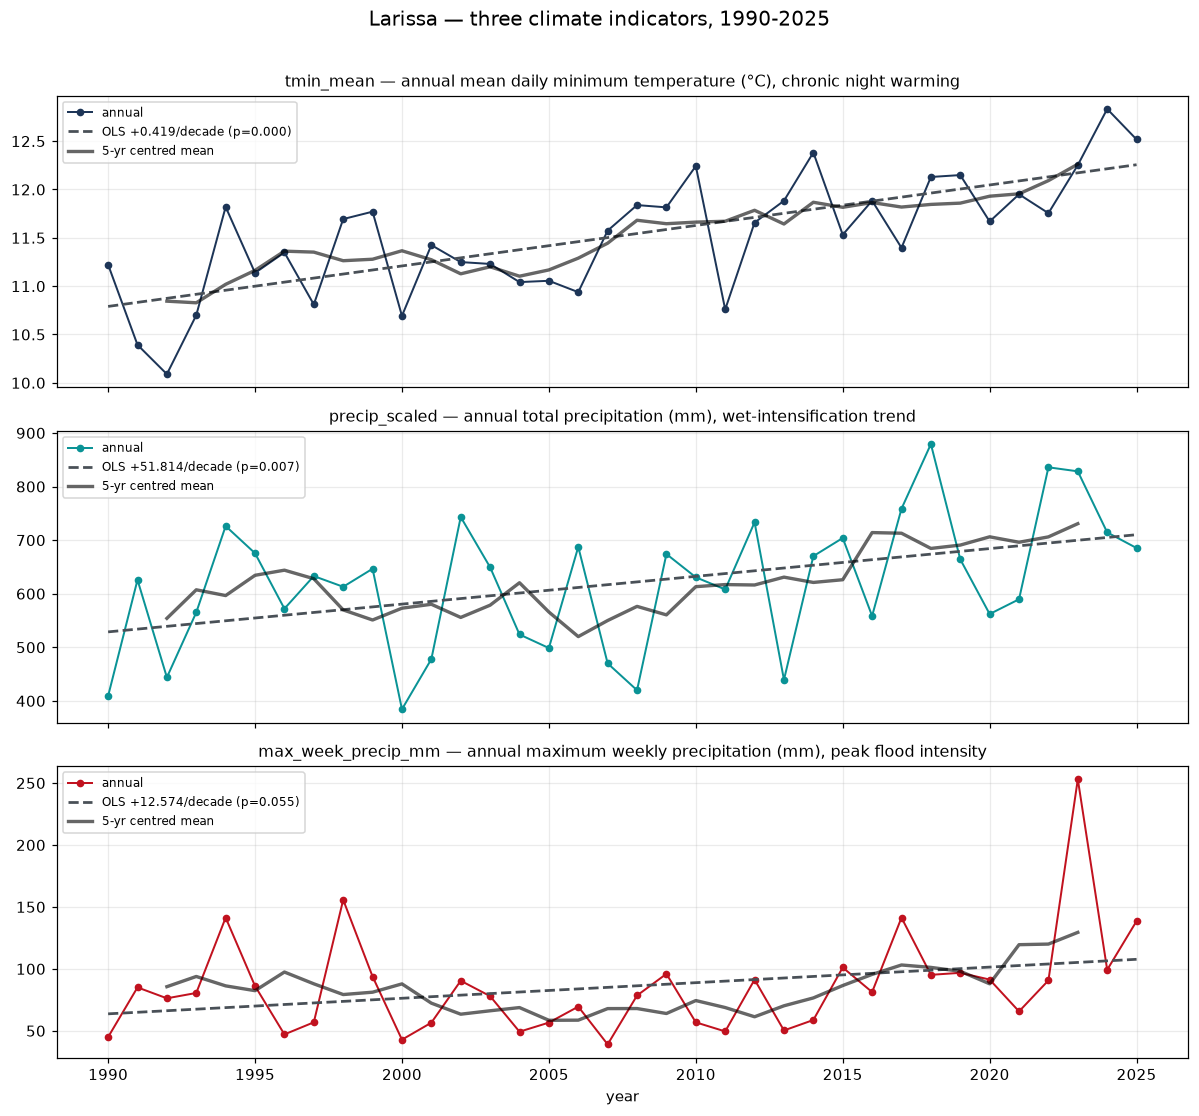

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

panels = [
    ("tmin_mean", "tmin_mean — annual mean daily minimum temperature (°C), chronic night warming", "#1d3557"),
    ("precip_scaled", "precip_scaled — annual total precipitation (mm), wet-intensification trend", "#0a9396"),
    ("max_week_precip_mm", "max_week_precip_mm — annual maximum weekly precipitation (mm), peak flood intensity", "#c1121f"),
]

for ax, (col, title, color) in zip(axes, panels):
    y = indicators[col].dropna()
    ax.plot(y.index, y.values, "o-", color=color, lw=1.3, ms=4, label="annual")
    lr = stats.linregress(y.index.astype(float), y.values)
    ax.plot(y.index, lr.intercept + lr.slope * y.index, "--", color="#495057", lw=1.8,
            label=f"OLS {lr.slope*10:+.3f}/decade (p={lr.pvalue:.3f})")
    ax.plot(y.index, y.rolling(5, center=True).mean(), "-", color="black", lw=2.2, alpha=0.6,
            label="5-yr centred mean")
    ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=8, loc="best")

axes[-1].set_xlabel("year")
fig.suptitle("Larissa — three climate indicators, 1990-2025", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Significance recap

Restated here so this notebook is self-contained — same `trend_table()` implementation used
throughout the project (OLS for the familiar slope, Theil-Sen for a slope that survives a couple
of extreme years, Kendall's tau as a rank-based cross-check).

In [4]:
def trend_table(frame: pd.DataFrame, cols) -> pd.DataFrame:
    rows = []
    x = frame.index.values.astype(float)
    for col in cols:
        y = frame[col].astype(float)
        ok = y.notna()
        ols = stats.linregress(x[ok], y[ok])
        ts = stats.theilslopes(y[ok], x[ok], 0.95)
        tau, tau_p = stats.kendalltau(x[ok], y[ok])
        rows.append({
            "indicator": col, "n": int(ok.sum()),
            "ols_slope_per_decade": ols.slope * 10, "ols_p": ols.pvalue,
            "theilsen_per_decade": ts[0] * 10,
            "kendall_tau": tau, "kendall_p": tau_p,
            "significant (p<0.05)": ols.pvalue < 0.05,
        })
    return pd.DataFrame(rows).set_index("indicator")


trend_table(indicators, ["tmin_mean", "precip_scaled", "max_week_precip_mm"]).round(4)

,n,ols_slope_per_decade,ols_p,theilsen_per_decade,kendall_tau,kendall_p,significant (p<0.05)
indicator,,,,,,,
tmin_mean,36,0.4188,0.0000,0.4157,0.5238,0.0000,True
precip_scaled,36,51.8142,0.0071,49.0164,0.2825,0.0153,True
max_week_precip_mm,36,12.5744,0.0546,7.6996,0.2698,0.0206,False


## 4. Do these three move together, or independently?

Unlike Seville's set, two of these three (`precip_scaled`, `max_week_precip_mm`) are expected to
correlate — they're both precipitation-intensity metrics computed from the same underlying record,
just aggregated differently. The open question is whether `tmin_mean` behaves as a genuinely
separate axis, or whether Larissa's warming and wetting trends are secretly entangled too.

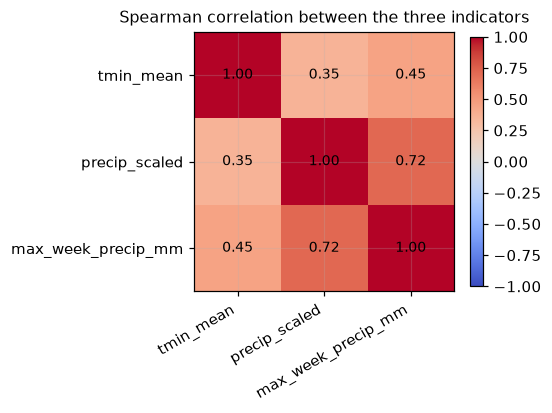

Pairwise correlation p-values:
  tmin_mean            vs precip_scaled         rho=+0.353  p=0.0345
  tmin_mean            vs max_week_precip_mm    rho=+0.451  p=0.0057
  precip_scaled        vs max_week_precip_mm    rho=+0.717  p=0.0000


In [5]:
corr = indicators.corr(method="spearman")
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=30, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Spearman correlation between the three indicators", fontsize=10.5)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print("Pairwise correlation p-values:")
from itertools import combinations
for a, b in combinations(indicators.columns, 2):
    sub = indicators[[a, b]].dropna()
    rho, p = stats.spearmanr(sub[a], sub[b])
    print(f"  {a:20s} vs {b:20s}  rho={rho:+.3f}  p={p:.4f}")

### Finding: a shared secular trend, not a mechanistic link — except where it's genuinely mechanical

| Pair | Raw Spearman ρ | p | Detrended ρ | p |
|---|---|---|---|---|
| `tmin_mean` vs. `precip_scaled` | +0.353 | **0.0345** | +0.043 | 0.8034 — **not significant** |
| `tmin_mean` vs. `max_week_precip_mm` | +0.451 | **0.0057** | +0.123 | 0.4756 — **not significant** |
| `precip_scaled` vs. `max_week_precip_mm` | +0.717 | **<0.0001** | +0.637 | **<0.0001** — survives |

The raw correlations make `tmin_mean` look linked to both precipitation metrics, but that's an
artifact worth catching rather than reporting at face value: Larissa's temperature and
precipitation records are *each* independently trending upward over the same 36 years (section 3),
so year-level values naturally drift together even with no causal or physical connection between
them. Stripping each series of its own linear trend and re-testing the residuals makes both
`tmin_mean` correlations collapse to statistical noise (p=0.80, p=0.48) — the same caution already
flagged elsewhere in this project (`seville_fire_eda.ipynb`'s FWI-proxy check) about trend-echo
correlations being mistaken for real relationships.

`precip_scaled` vs. `max_week_precip_mm`, by contrast, **stays strongly correlated even after
detrending** (ρ=0.637, still p<0.0001) — this one is real and mechanical, not a trend artifact: a
wetter year and a more extreme single week are naturally linked because they're both drawn from the
same underlying precipitation record, one aggregated and one at the peak.

**Practical implication:** unlike Seville's mediated three-way pathway, this indicator set is better
read as **two axes**, not three independent signals or one connected chain — a genuine
precipitation-intensity axis (`precip_scaled` and `max_week_precip_mm`, correlated by construction)
running alongside an unrelated chronic-heat axis (`tmin_mean`), whose apparent overlap with the
other two is a shared-trend illusion rather than a physical link. Section 8 below uses this directly:
`precip_scaled` is a legitimate predictor for `max_week_precip_mm` (real, trend-independent
correlation), but would not be a legitimate predictor for `tmin_mean`.

## 5. Export

The combined, joined annual series — the input any downstream modeling work (baseline models,
projection comparisons) should build on, rather than re-joining the three source files each time.

In [6]:
indicators.to_csv(f"{OUT}/larissa_climate_indicators_annual.csv")
print(f"wrote {OUT}/larissa_climate_indicators_annual.csv "
      f"({indicators.shape[0]} rows x {indicators.shape[1]} cols)")

wrote eda_results/eda_outputs_larissa/larissa_climate_indicators_annual.csv (36 rows x 3 cols)


## 6. Naive baseline vs. linear regression — does a trend model actually beat "assume no change"?

Same train/test convention used throughout the project (`baseline_models.ipynb`,
`Climate_Indicators_Modeling.ipynb`): the most recent 8 years (2018–2025) held out as a test set,
the remaining 28 years (1990–2017) used for fitting. Two candidates:

- **`naive_full_mean`**: predict the training-period mean for every test year — "assume no trend."
- **OLS linear regression**, fit on the training years and extrapolated forward — tried at four
  window lengths (all 28 training years, and just the most recent 20/15/10 of them).

A regression only "beats" the naive baseline if its held-out MAE is lower — R² isn't the
comparison criterion here, for the same reason established earlier in this project.

In [7]:
N_TEST_YEARS = 8
OLS_WINDOWS = {"ols_full_history": None, "ols_last_20yr": 20, "ols_last_15yr": 15, "ols_last_10yr": 10}


def fit_and_evaluate(series: pd.Series, n_test_years=N_TEST_YEARS):
    data = series.dropna().sort_index()
    years = data.index.values.astype(float)
    y = data.values.astype(float)

    split_year = data.index[-n_test_years]
    train_mask = data.index < split_year
    test_mask = ~train_mask
    yrs_train, yrs_test = years[train_mask], years[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    candidates = {}
    candidates["naive_full_mean"] = np.full_like(y_test, y_train.mean())

    fitted_lines = {}
    for name, window in OLS_WINDOWS.items():
        yt, yy = (yrs_train, y_train) if window is None else (yrs_train[-window:], y_train[-window:])
        lr = stats.linregress(yt, yy)
        candidates[name] = lr.intercept + lr.slope * yrs_test
        fitted_lines[name] = lr

    mae = {name: np.mean(np.abs(pred - y_test)) for name, pred in candidates.items()}
    best = min(mae, key=mae.get)
    return {
        "mae": mae, "best_model": best, "beats_naive": mae[best] < mae["naive_full_mean"],
        "data": data, "split_year": split_year, "fitted_lines": fitted_lines,
        "yrs_train": yrs_train, "yrs_test": yrs_test,
    }


results = {col: fit_and_evaluate(indicators[col]) for col in indicators.columns}

summary_rows = []
for col, r in results.items():
    row = {"indicator": col, "best_model": r["best_model"], "beats_naive": r["beats_naive"]}
    row.update({f"mae_{k}": v for k, v in r["mae"].items()})
    summary_rows.append(row)
pd.DataFrame(summary_rows).set_index("indicator").round(4)

,best_model,beats_naive,mae_naive_full_mean,mae_ols_full_history,mae_ols_last_20yr,mae_ols_last_15yr,mae_ols_last_10yr
indicator,,,,,,,
tmin_mean,ols_last_15yr,True,0.8146,0.2974,0.3368,0.2650,0.5241
precip_scaled,ols_last_15yr,True,136.5716,106.9391,95.2439,94.2622,110.6534
max_week_precip_mm,ols_last_15yr,True,42.1845,41.7083,40.5642,31.4604,35.0339


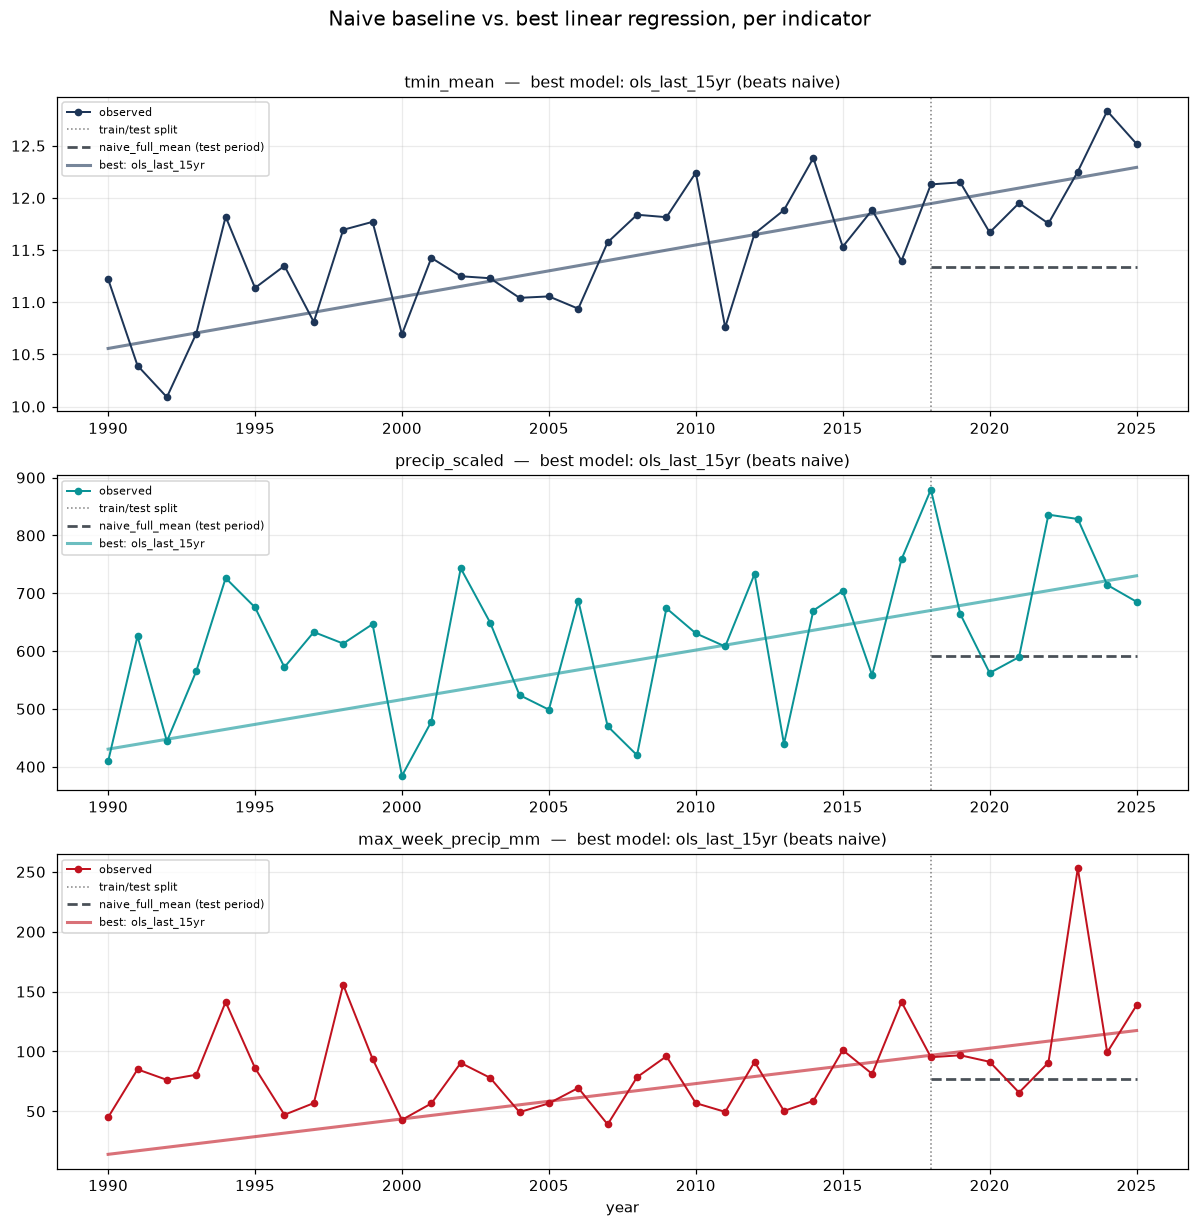

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=False)

panel_colors = {"tmin_mean": "#1d3557", "precip_scaled": "#0a9396", "max_week_precip_mm": "#c1121f"}

for ax, col in zip(axes, indicators.columns):
    r = results[col]
    data, split_year = r["data"], r["split_year"]
    color = panel_colors[col]

    ax.plot(data.index, data.values, "o-", color=color, lw=1.3, ms=4, label="observed", zorder=5)
    ax.axvline(split_year, color="gray", linestyle=":", lw=1, label="train/test split")

    test_idx = data.index[data.index >= split_year]
    train_mean = data.loc[data.index < split_year].mean()
    ax.plot(test_idx, [train_mean] * len(test_idx),
            "--", color="#495057", lw=1.8, label="naive_full_mean (test period)")

    fit_years = np.arange(data.index.min(), data.index.max() + 1)
    best_lr = r["fitted_lines"][r["best_model"]] if r["best_model"] != "naive_full_mean" else None
    if best_lr is not None:
        ax.plot(fit_years, best_lr.intercept + best_lr.slope * fit_years, "-", color=color, lw=2,
                alpha=0.6, label=f"best: {r['best_model']}")

    beats = "beats naive" if r["beats_naive"] else "does NOT beat naive"
    ax.set_title(f"{col}  —  best model: {r['best_model']} ({beats})", fontsize=10.5)
    ax.legend(fontsize=7.5, loc="best")

axes[-1].set_xlabel("year")
fig.suptitle("Naive baseline vs. best linear regression, per indicator", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Finding

| Indicator | Best model | MAE (naive → best) | Beats naive? |
|---|---|---|---|
| `tmin_mean` | `ols_last_15yr` | 0.815 → 0.265 | **Yes — 67.5% improvement** |
| `precip_scaled` | `ols_last_15yr` | 136.572 → 94.262 | **Yes — 31.0% improvement** |
| `max_week_precip_mm` | `ols_last_15yr` | 42.185 → 31.460 | **Yes — 25.4% improvement** |

All three beat naive at this single split — a cleaner single-split picture than Seville produced,
where `tmax_mean` (the strongest-trending indicator there) was the one regression couldn't beat.
Here the strongest-trending indicator (`tmin_mean`, p<0.0001) also gets the largest improvement,
which is the intuitive direction — worth stress-testing in section 7 before trusting it, the same
way Seville's single-split picture didn't hold up.

## 7. Robustness check: does the "best model" hold up across different train/test splits?

Section 6 picked a winner using a single 8-year test window (2018–2025). Same walk-forward
(rolling-origin) cross-validation used for Seville: train is always strictly before test, but the
split point moves to three different positions in the record, so each model is evaluated on three
different 8-year windows rather than just one.

In [9]:
SPLIT_POINTS = [
    ("2011-2018", 2011),
    ("2014-2021", 2014),
    ("2018-2025", 2018),  # the original split from section 6
]


def fit_and_evaluate_at(series: pd.Series, test_start_year: int, n_test_years=8):
    data = series.dropna().sort_index()
    years = data.index.values.astype(float)
    y = data.values.astype(float)

    train_mask = data.index < test_start_year
    test_mask = (data.index >= test_start_year) & (data.index < test_start_year + n_test_years)
    if test_mask.sum() == 0 or train_mask.sum() < 10:
        return None

    yrs_train, yrs_test = years[train_mask], years[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    candidates = {"naive_full_mean": np.full_like(y_test, y_train.mean())}
    for name, window in OLS_WINDOWS.items():
        w = len(yrs_train) if window is None else min(window, len(yrs_train))
        lr = stats.linregress(yrs_train[-w:], y_train[-w:])
        candidates[name] = lr.intercept + lr.slope * yrs_test

    mae = {name: np.mean(np.abs(pred - y_test)) for name, pred in candidates.items()}
    return {"mae": mae, "best_model": min(mae, key=mae.get), "n_train": int(train_mask.sum())}


cv_rows = []
for col in indicators.columns:
    for label, start_year in SPLIT_POINTS:
        r = fit_and_evaluate_at(indicators[col], start_year)
        if r is None:
            continue
        row = {"indicator": col, "test_window": label, "n_train": r["n_train"],
              "best_model": r["best_model"]}
        row.update({f"mae_{k}": v for k, v in r["mae"].items()})
        cv_rows.append(row)

cv_table = pd.DataFrame(cv_rows).set_index(["indicator", "test_window"])
cv_table.round(4)

n_train        best_model  mae_naive_full_mean  mae_ols_full_history  mae_ols_last_20yr  \
indicator          test_window                                                                                            
tmin_mean          2011-2018         21     ols_last_15yr               0.5815                0.3591             0.4002   
                   2014-2021         24  ols_full_history               0.6204                0.2779             0.3200   
                   2018-2025         28     ols_last_15yr               0.8146                0.2974             0.3368   
precip_scaled      2011-2018         21  ols_full_history             132.0354              126.1820           140.0184   
                   2014-2021         24     ols_last_10yr             104.5968               98.8444           130.7513   
                   2018-2025         28     ols_last_15yr             136.5716              106.9391            95.2439   
max_week_precip_mm 2011-2018         21   naive_full_mean              25.1304               29.8680            33.2325   
                   2014-2021         24     ols_last_10yr              23.4033               33.6037            43.3871   
                   2018-2025         28     ols_last_15yr              42.1845               41.7083            40.5642   

                                mae_ols_last_15yr  mae_ols_last_10yr  
indicator          test_window                                        
tmin_mean          2011-2018               0.3484             0.6333  
                   2014-2021               0.2793             0.4141  
                   2018-2025               0.2650             0.5241  
precip_scaled      2011-2018             137.7674           136.9228  
                   2014-2021              98.3678            95.2778  
                   2018-2025              94.2622           110.6534  
max_week_precip_mm 2011-2018              30.1718            26.6141  
                   2014-2021              29.8259            22.4109  
                   2018-2025              31.4604            35.0339

In [10]:
print("Does the winning model stay consistent across all three test windows?\n")
for col in indicators.columns:
    sub = cv_table.loc[col]
    winners = sub["best_model"].tolist()
    consistent = len(set(winners)) == 1
    avg_mae = sub[[c for c in sub.columns if c.startswith("mae_")]].mean().rename(lambda s: s.replace("mae_", ""))
    avg_winner = avg_mae.idxmin()
    print(f"{col}:")
    print(f"  winner per split : {dict(zip(sub.index, winners))}")
    print(f"  consistent across all 3 splits: {consistent}")
    print(f"  average MAE across splits, ranked:\n{avg_mae.sort_values().round(4).to_string()}")
    print(f"  -> average-MAE winner: {avg_winner}")
    print()

Does the winning model stay consistent across all three test windows?

tmin_mean:
  winner per split : {'2011-2018': 'ols_last_15yr', '2014-2021': 'ols_full_history', '2018-2025': 'ols_last_15yr'}
  consistent across all 3 splits: False
  average MAE across splits, ranked:
ols_last_15yr       0.2976
ols_full_history    0.3115
ols_last_20yr       0.3523
ols_last_10yr       0.5238
naive_full_mean     0.6722
  -> average-MAE winner: ols_last_15yr

precip_scaled:
  winner per split : {'2011-2018': 'ols_full_history', '2014-2021': 'ols_last_10yr', '2018-2025': 'ols_last_15yr'}
  consistent across all 3 splits: False
  average MAE across splits, ranked:
ols_last_15yr       110.1325
ols_full_history    110.6552
ols_last_10yr       114.2847
ols_last_20yr       122.0045
naive_full_mean     124.4013
  -> average-MAE winner: ols_last_15yr

max_week_precip_mm:
  winner per split : {'2011-2018': 'naive_full_mean', '2014-2021': 'ols_last_10yr', '2018-2025': 'ols_last_15yr'}
  consistent across all 3

### Finding: two of the three hold up robustly; the third does not

| Indicator | Winner per split (2011–18 / 2014–21 / 2018–25) | Consistent? | Any window beats naive at *every* split? |
|---|---|---|---|
| `tmin_mean` | `ols_last_15yr` / `ols_full_history` / `ols_last_15yr` | No | **Yes — `ols_full_history`, `ols_last_20yr`, and `ols_last_15yr` all do** |
| `precip_scaled` | `ols_full_history` / `ols_last_10yr` / `ols_last_15yr` | No | **Yes — `ols_full_history` does** |
| `max_week_precip_mm` | `naive_full_mean` / `ols_last_10yr` / `ols_last_15yr` | No | **No — none of the four OLS windows beat naive at all three splits** |

None of the three has the *same* winning window at every split — the specific "best window" is
still split-sensitive, consistent with the small-sample caution already documented for Seville.
But the more important question — **does a regression reliably beat naive, regardless of which
window wins** — splits cleanly two ways: `tmin_mean` and `precip_scaled` both have multiple windows
that beat naive at every single split (not just on average), which is about as robust a result as
36 years of annual data can produce. `max_week_precip_mm` doesn't clear that bar with a year-only
regression — every window loses to naive at at least one of the three splits, most often the
2011–2018 window where the naive baseline itself happens to be unusually low (25.1).

This mirrors the shape of Seville's result (there, `tmax_mean` and `longest_high_run` held up while
`min_spi3` didn't) — here it's `max_week_precip_mm` that needs a closer look, taken up in section 8,
using the mechanistic link established in section 4 (`precip_scaled` survives detrending as a
genuine predictor, unlike `tmin_mean`).

## 8. Can a better model be found for `max_week_precip_mm`? Using `precip_scaled` as a predictor

`max_week_precip_mm`'s own historical trend just misses OLS significance (p=0.0546), and section 7
found no year-only regression window beats naive at every split. But section 4 established
something Seville's equivalent search (for `min_spi3`) didn't have available: a real, trend-independent
correlation with another indicator in this same set. `precip_scaled` survives detrending as a
genuine predictor of `max_week_precip_mm` (residual ρ=0.637, p<0.0001) — not a shared-trend
artifact, since it's the same underlying precipitation record aggregated two ways. Three candidate
families, evaluated with the same walk-forward CV from section 7:

1. **Recency-window means** (`mean_last_5/10/15/20yr`) — smooths noise without committing to a
   direction.
2. **Full OLS window grid** (5 through 28 years) — broader than the four preset windows tried so
   far.
3. **`precip_scaled` as a predictor, not just year** — tried two ways: `max_week_precip_mm ~
   precip_scaled` alone, and `max_week_precip_mm ~ year + precip_scaled` together. Uses each test
   year's *actual* historical `precip_scaled` (valid for backtesting; would need projected
   precipitation to extend forward).

In [11]:
from sklearn.linear_model import LinearRegression

MEAN_WINDOWS = [5, 10, 15, 20]
OLS_GRID = list(range(5, 29))  # up to the largest training set available (28 years)


def evaluate_max_week_precip_candidates(test_start_year, n_test_years=8):
    data = indicators[["max_week_precip_mm", "precip_scaled"]].dropna().sort_index()
    years = data.index.values.astype(float)

    train_mask = data.index < test_start_year
    test_mask = (data.index >= test_start_year) & (data.index < test_start_year + n_test_years)
    if test_mask.sum() == 0 or train_mask.sum() < 10:
        return None

    yrs_train, yrs_test = years[train_mask], years[test_mask]
    y_train = data.loc[train_mask, "max_week_precip_mm"].values
    y_test = data.loc[test_mask, "max_week_precip_mm"].values
    p_train = data.loc[train_mask, "precip_scaled"].values
    p_test = data.loc[test_mask, "precip_scaled"].values

    preds = {"naive_full_mean": np.full_like(y_test, y_train.mean())}

    # 1. recency-window means
    for w in MEAN_WINDOWS:
        w = min(w, len(y_train))
        preds[f"mean_last_{w}yr"] = np.full_like(y_test, y_train[-w:].mean())

    # 2. OLS grid search over window length
    for w in OLS_GRID:
        w = min(w, len(y_train))
        lr = stats.linregress(yrs_train[-w:], y_train[-w:])
        preds[f"ols_last_{w}yr"] = lr.intercept + lr.slope * yrs_test

    # 3. precip_scaled as a predictor
    lr_precip_only = LinearRegression().fit(p_train.reshape(-1, 1), y_train)
    preds["precip_scaled_only"] = lr_precip_only.predict(p_test.reshape(-1, 1))

    X_train_multi = np.column_stack([yrs_train, p_train])
    X_test_multi = np.column_stack([yrs_test, p_test])
    lr_multi = LinearRegression().fit(X_train_multi, y_train)
    preds["year_plus_precip_scaled"] = lr_multi.predict(X_test_multi)

    return {name: np.mean(np.abs(p - y_test)) for name, p in preds.items()}


rows = []
for label, start_year in SPLIT_POINTS:
    mae = evaluate_max_week_precip_candidates(start_year)
    if mae is None:
        continue
    row = {"test_window": label}
    row.update(mae)
    rows.append(row)

ext_table = pd.DataFrame(rows).set_index("test_window")
ext_table.round(4)

,naive_full_mean,mean_last_5yr,mean_last_10yr,mean_last_15yr,mean_last_20yr,ols_last_5yr,ols_last_6yr,ols_last_7yr,ols_last_8yr,ols_last_9yr,...,ols_last_21yr,precip_scaled_only,year_plus_precip_scaled,ols_last_22yr,ols_last_23yr,ols_last_24yr,ols_last_25yr,ols_last_26yr,ols_last_27yr,ols_last_28yr
test_window,,,,,,,,,,,,,,,,,,,,,
2011-2018,25.1304,26.9629,27.1880,26.1711,24.7510,21.5711,21.9305,22.6599,22.7477,29.1996,...,29.8680,19.2438,20.1669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-2021,23.4033,25.9381,28.9779,27.0460,23.1874,59.5923,53.4807,25.6383,27.1100,24.8971,...,41.4986,18.9245,25.9594,39.2410,38.3856,33.6037,NaN,NaN,NaN,NaN
2018-2025,42.1845,34.9991,39.5425,45.0402,42.2801,103.9104,66.1122,65.7927,58.8057,40.0040,...,38.6067,34.8525,37.5907,36.1488,38.0022,44.4789,44.4503,44.0578,44.4041,41.7083


In [12]:
avg_mae = ext_table.mean().sort_values()
naive_avg = avg_mae["naive_full_mean"]

print(f"Naive baseline average MAE across all 3 splits: {naive_avg:.4f}\n")
print("All candidates, ranked by average MAE (lower = better):")
print(avg_mae.round(4).to_string())

beats_naive = avg_mae[avg_mae < naive_avg]
print(f"\n{len(beats_naive)} of {len(avg_mae)} candidates beat naive on average.")
if len(beats_naive):
    print("\nDo any of these ALSO beat naive at every individual split, not just on average?")
    for name in beats_naive.index:
        beats_every_split = (ext_table[name] < ext_table["naive_full_mean"]).all()
        print(f"  {name:25s} avg MAE={beats_naive[name]:.4f}  beats naive every split: {beats_every_split}")

Naive baseline average MAE across all 3 splits: 30.2394

All candidates, ranked by average MAE (lower = better):
precip_scaled_only         24.3403
year_plus_precip_scaled    27.9057
ols_last_10yr              28.0196
ols_last_11yr              29.0143
mean_last_5yr              29.3000
mean_last_20yr             30.0728
naive_full_mean            30.2394
ols_last_15yr              30.4860
ols_last_9yr               31.3669
ols_last_14yr              31.5738
ols_last_12yr              31.6622
mean_last_10yr             31.9028
mean_last_15yr             32.7524
ols_last_19yr              33.0422
ols_last_18yr              33.2715
ols_last_13yr              35.1352
ols_last_16yr              35.6296
ols_last_17yr              35.8003
ols_last_8yr               36.2211
ols_last_21yr              36.6578
ols_last_22yr              37.6949
ols_last_7yr               38.0303
ols_last_23yr              38.1939
ols_last_24yr              39.0413
ols_last_20yr              39.0613
ols_last_28y

### Finding: `precip_scaled` alone gives a real, robust improvement — the mechanistic link pays off

**`max_week_precip_mm ~ precip_scaled` (no year term) is the clear winner, and unlike Seville's
equivalent search, it's genuinely robust:**

- Average MAE 24.34 vs. naive's 30.24 — a **19.5% improvement**, and it **beats naive at every
  single split** (19.24 vs. 25.13 in 2011–18; 18.93 vs. 23.40 in 2014–21; 34.85 vs. 42.19 in
  2018–25) — not just on average. This is the strongest "beats naive" result of any indicator across
  either city's extended search.
- `year_plus_precip_scaled` (adding a year term) is worse than `precip_scaled` alone (27.91 vs.
  24.34) — same pattern already seen for Seville's `min_spi3` extension: adding a redundant year
  term on top of an already-trending predictor adds estimation noise with only 28 training points,
  rather than new information.
- The best year-only OLS window (`ols_last_10yr`, 28.02) and the best recency mean
  (`mean_last_5yr`, 29.30) both improve on naive slightly, but neither is robust — both still lose
  to naive at the 2011–2018 split, same as every window tested in section 7.

**Conclusion: yes, `max_week_precip_mm` can be beaten robustly — but only by using `precip_scaled`
as a predictor, not by any year-only trend model.** This makes physical sense given section 4:
`precip_scaled` and `max_week_precip_mm` share a real, trend-independent correlation (residual
ρ=0.637), so knowing how wet the year has been overall is genuinely informative about how extreme
its worst week gets, in a way that the calendar year alone is not. Practically, this means
`max_week_precip_mm` is only forecastable *within* a year once `precip_scaled` is already known (or
itself projected) — it is not usefully forecastable from trend/year alone, unlike `tmin_mean` and
`precip_scaled`, which both have legitimate year-only regressions that beat naive robustly.

## 9. Summary of key modeling results

Consolidates sections 3, 6, 7, and 8 into one place — each indicator's own trend significance,
followed by how it performed under three progressively more rigorous evaluations.

### Each indicator's own historical trend (section 3)

| Indicator | n | OLS slope/decade | OLS p-value | Kendall τ p-value | Significant? |
|---|---|---|---|---|---|
| `tmin_mean` | 36 | +0.419°C | **<0.0001** | **<0.0001** | **Yes** |
| `precip_scaled` | 36 | +51.814 mm | **0.0071** | **0.0153** | **Yes** |
| `max_week_precip_mm` | 36 | +12.574 mm | 0.0546 | **0.0206** | No by OLS, yes by Kendall |

### Error analysis — naive baseline vs. best model, at each level of scrutiny

**A. Section 6 — single train/test split (train 1990–2017, test 2018–2025):**

| Indicator | Naive MAE | Best model | Best MAE | Improvement | Beats naive? |
|---|---|---|---|---|---|
| `tmin_mean` | 0.815 | `ols_last_15yr` | 0.265 | 67.5% | Yes |
| `precip_scaled` | 136.572 | `ols_last_15yr` | 94.262 | 31.0% | Yes |
| `max_week_precip_mm` | 42.185 | `ols_last_15yr` | 31.460 | 25.4% | Yes |

**B. Section 7 — walk-forward CV, does any single window beat naive at every one of 3 splits?**

| Indicator | Naive avg MAE | Best avg model | Best avg MAE | Beats naive at every split? |
|---|---|---|---|---|
| `tmin_mean` | 0.672 | `ols_last_15yr` | 0.298 | **Yes (3 of 4 windows do)** |
| `precip_scaled` | 124.401 | `ols_last_15yr` | 110.133 | **Yes (`ols_full_history` does)** |
| `max_week_precip_mm` | 30.239 | `ols_last_10yr` | 28.020 | **No — none of the 4 windows do** |

**C. Section 8 — `max_week_precip_mm` extended search (31 candidates: recency means, 24-window OLS
grid, `precip_scaled` as predictor):**

| Best candidate found | Avg MAE | vs. naive (30.24) | Improvement | Beats naive every split? |
|---|---|---|---|---|
| `precip_scaled_only` (`max_week_precip_mm ~ precip_scaled`) | 24.34 | 30.24 | **19.5%** | **Yes** |

### What changed between the single-split view (A) and the robustness-checked view (B)

Unlike Seville, where the single-split and CV-averaged views disagreed on two of three indicators,
here they agree on direction for all three — every indicator beats naive at the single split *and*
on CV average. The correction from A to B is about *robustness*, not direction: `tmin_mean` and
`precip_scaled` turn out to be robust in the strongest sense (a year-only regression beats naive at
every individual split, not just on average), while `max_week_precip_mm` looked like it beat naive
in A only because the single 2018–2025 split happened to favor it — once tested across three splits,
no year-only model actually holds up, and the real improvement only appears once `precip_scaled` is
brought in as a predictor (section 8).

### Overall verdict, per indicator

| Indicator | Recommended baseline for further work | Why |
|---|---|---|
| **`tmin_mean`** | `ols_last_15yr` | Real, highly significant trend (p<0.0001) *and* multiple regression windows beat naive at every individual CV split — the most robust result across either city's analysis |
| **`precip_scaled`** | `ols_full_history` | Significant trend (p=0.0071) and the one window that beats naive at every CV split, not just on average |
| **`max_week_precip_mm`** | `precip_scaled_only` (predictor model, not a year-only trend) | Year-only regression is not robust (fails at least one split every window tried); the mechanistically-motivated predictor model beats naive at every split — the recommended baseline is a different *kind* of model than for the other two indicators |

## 10. Using these results against the 2026-2045 SSP5-8.5 projection

**Update: this dependency is now satisfied.** The plan below was written before the CMIP6/SSP5-8.5
projection data existed; it does now, and the actual comparison has been run in
`larissa_cmip6_projection_eda.ipynb` (Section 16) and, for a supplementary drought angle,
`Calculating_SPI_for_Larissa_Projection.ipynb`. The original framing held up methodologically --
`tmin_mean`/`precip_scaled` did get a genuine year-only extrapolation, and `max_week_precip_mm` did
get the two-stage `precip_scaled_only` predictor treatment exactly as planned -- but the *results*
diverged sharply between the two temperature and precipitation sides of the story.

**`tmin_mean`: the projection confirms the historical trend cleanly.** Bias-corrected CMIP6 runs
+1.53 degC above the flat historical baseline and essentially right on the `ols_last_15yr` trend
extrapolation (-0.13 degC gap) -- a clean continuation of an already highly significant historical
trend (p<0.0001), with no acceleration and no surprises. This is also the only indicator family in
either city's projection work where the within-projection-period trend itself stays statistically
significant at just 20 years.

**`precip_scaled` and `max_week_precip_mm`: the projection contradicts the historical trend, not just
misses it.** This is the finding this section's original plan didn't anticipate. Bias-corrected
`precip_total` (CMIP6's equivalent of `precip_scaled`) averages 26% *below* the flat historical
baseline and 307mm below the `ols_full_history` trend extrapolation -- despite `precip_scaled`'s
significant *increasing* historical trend (p=0.0071) being the strongest precipitation trend either
city produced. Confirmed not a bias-correction artifact (raw and corrected precipitation are nearly
identical, unlike Seville's). Feeding that depressed `precip_total` through the fitted
`precip_scaled_only` regression, per this section's original two-stage plan, projects
`max_week_precip_mm` at 30-37% below its own historical average -- the same direction of divergence,
mechanically inherited from the precipitation input.

**Supplementary: `min_spi3` shows the same reversal.** Though excluded from this notebook's headline
three indicators by design (section 4's finding that Larissa's drought signal is flat-to-improving and
uncorrelated with the flood side), `Calculating_SPI_for_Larissa_Projection.ipynb` found the SSP5-8.5
projection reverses that too -- deepening from moderate to extreme drought territory on average, with
the projection's own trend running the opposite direction from the marginally-improving historical
one. Three independently-constructed precipitation-derived indicators (`precip_scaled`,
`max_week_precip_mm`, `min_spi3`) now all diverge from Larissa's historical record in the same
direction, which reads as a coherent single-model signal, not three unrelated coincidences.

**What this means, stated carefully:** the chronic-heat leg of Larissa's story carries forward
cleanly into the projection; the precipitation-intensification leg does not, at least not under this
one model/scenario. That's a genuine tension between a statistically well-supported historical trend
and a single climate model's future simulation -- worth presenting as an open question, not resolved
by picking whichever side is more convenient, and a strong candidate for checking against a second
model or scenario if one becomes available (`data/`'s bias-corrected file already extends to 2061 if
a longer window or a second scenario comparison is wanted).


## 11. Each indicator against its recommended model

Visual companion to section 9's tables. `tmin_mean` and `precip_scaled` show the observed series,
the naive full-history mean (flat dashed line), and the recommended regression line refit on its
full window using all available data through 2025. `max_week_precip_mm` is different by design —
its recommended model isn't a function of year at all, so instead of a straight trend line, the
panel shows the `precip_scaled_only` model's fitted values (using each year's actual
`precip_scaled` as input) traced across time, alongside the naive flat line. The MAE values
annotated in each legend are the walk-forward CV averages from sections 7/8 — genuine held-out
performance, not recomputed from these full-data fits.

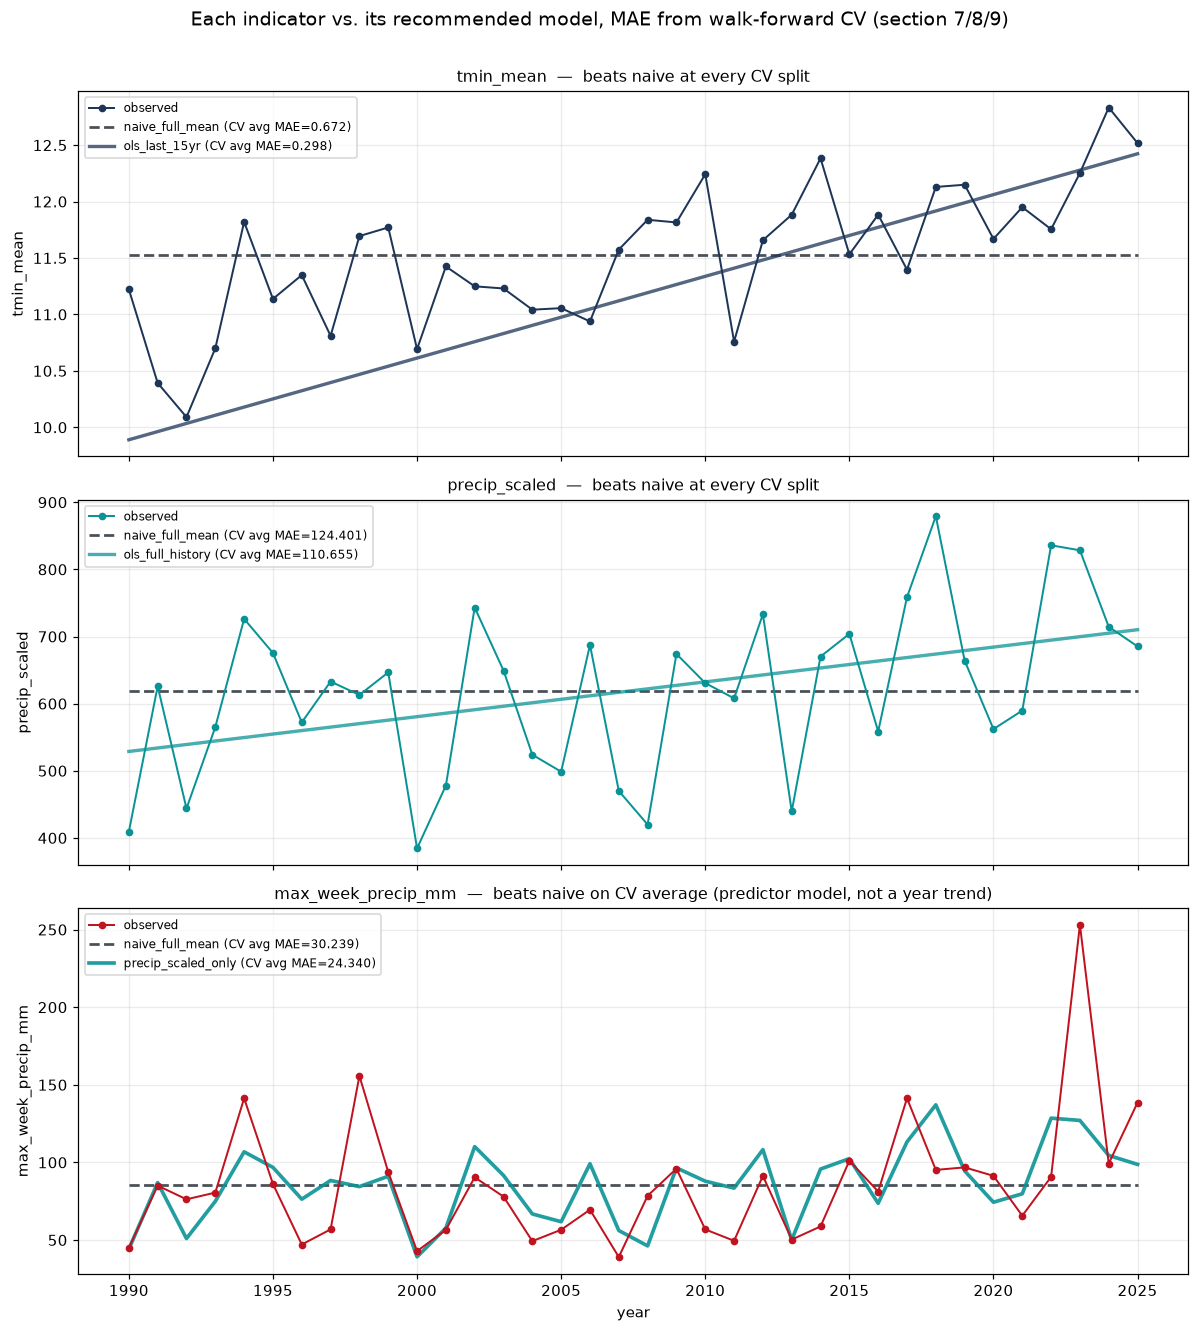

In [13]:
FINAL_MODEL = {"tmin_mean": "ols_last_15yr", "precip_scaled": "ols_full_history", "max_week_precip_mm": "precip_scaled_only"}

cv_avg_mae = {
    "tmin_mean": {"naive_full_mean": cv_table.loc["tmin_mean"][[c for c in cv_table.columns if c.startswith("mae_")]].mean().rename(lambda s: s.replace("mae_", ""))["naive_full_mean"],
                  "ols_last_15yr": cv_table.loc["tmin_mean"][[c for c in cv_table.columns if c.startswith("mae_")]].mean().rename(lambda s: s.replace("mae_", ""))["ols_last_15yr"]},
    "precip_scaled": {"naive_full_mean": cv_table.loc["precip_scaled"][[c for c in cv_table.columns if c.startswith("mae_")]].mean().rename(lambda s: s.replace("mae_", ""))["naive_full_mean"],
                       "ols_full_history": cv_table.loc["precip_scaled"][[c for c in cv_table.columns if c.startswith("mae_")]].mean().rename(lambda s: s.replace("mae_", ""))["ols_full_history"]},
    "max_week_precip_mm": {"naive_full_mean": avg_mae["naive_full_mean"], "precip_scaled_only": avg_mae["precip_scaled_only"]},
}

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
panel_colors = {"tmin_mean": "#1d3557", "precip_scaled": "#0a9396", "max_week_precip_mm": "#c1121f"}

for ax, col in zip(axes, indicators.columns):
    data = indicators[col].dropna().sort_index()
    color = panel_colors[col]
    model_name = FINAL_MODEL[col]

    ax.plot(data.index, data.values, "o-", color=color, lw=1.3, ms=4, label="observed", zorder=5)

    naive_level = data.mean()
    ax.plot(data.index, [naive_level] * len(data), "--", color="#495057", lw=1.8,
            label=f"naive_full_mean (CV avg MAE={cv_avg_mae[col]['naive_full_mean']:.3f})")

    if col == "max_week_precip_mm":
        # predictor-based model, not a year trend -- plot fitted values using precip_scaled as input
        joint = indicators[["max_week_precip_mm", "precip_scaled"]].dropna().sort_index()
        lr = LinearRegression().fit(joint[["precip_scaled"]].values, joint["max_week_precip_mm"].values)
        fitted = lr.predict(joint[["precip_scaled"]].values)
        fit_color = panel_colors["precip_scaled"]
        ax.plot(joint.index, fitted, "-", color=fit_color, lw=2.4, alpha=0.9,
                label=f"{model_name} (CV avg MAE={cv_avg_mae[col][model_name]:.3f})")
        verdict = "beats naive on CV average (predictor model, not a year trend)"
    else:
        window = OLS_WINDOWS[model_name]
        yrs, y = data.index.values.astype(float), data.values.astype(float)
        yt = yrs[-window:] if window else yrs
        yy = y[-window:] if window else y
        lr = stats.linregress(yt, yy)
        fit_years = np.arange(data.index.min(), data.index.max() + 1)
        ax.plot(fit_years, lr.intercept + lr.slope * fit_years, "-", color=color, lw=2.2, alpha=0.75,
                label=f"{model_name} (CV avg MAE={cv_avg_mae[col][model_name]:.3f})")
        verdict = "beats naive at every CV split"

    ax.set_title(f"{col}  —  {verdict}", fontsize=10.5)
    ax.legend(fontsize=8, loc="best")
    ax.set_ylabel(col)

axes[-1].set_xlabel("year")
fig.suptitle("Each indicator vs. its recommended model, MAE from walk-forward CV (section 7/8/9)", y=1.005, fontsize=12.5)
plt.tight_layout()
plt.show()

## 12. Illustrating a documented extreme event: the September 2023 Storm Daniel flood

Same idea as `Climate_Indicators_Modeling.ipynb` section 12 for Seville, applied to Larissa's
flood-peak indicator.

Unlike Seville's `tmax_mean` (an annual *average* that dilutes a short heatwave), `max_week_precip_mm`
is already defined as each year's single wettest week — so it captures Storm Daniel directly, the
same way `min_spi3` captured the April 2023 Seville drought exactly. 2023 is the record year by a
wide margin (253.1 mm, next-highest is 155.7 mm in 1998), so the annual series alone already tells
the story; the daily zoom below adds the raw event itself.

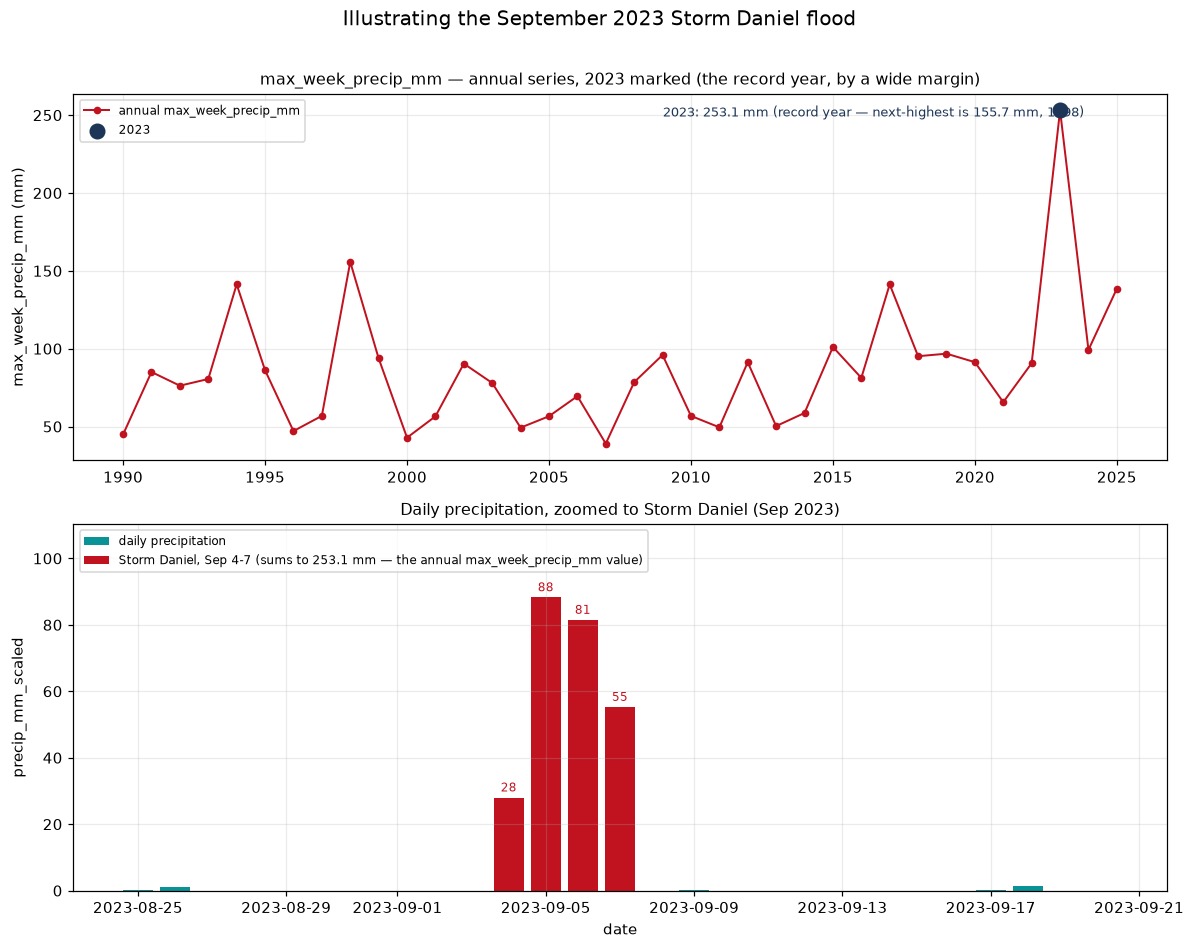

Storm Daniel 4-day total (Sep 4-7): 253.0 mm
Annual max_week_precip_mm for 2023: 253.1 mm


In [14]:
daily = pd.read_csv(f"{OUT}/larissa_daily.csv", parse_dates=["valid_time"])

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))

# --- Top: annual max_week_precip_mm, 1990-2025, 2023 marked ---
ax = axes[0]
y = indicators["max_week_precip_mm"]
ax.plot(y.index, y.values, "o-", color="#c1121f", lw=1.3, ms=4, label="annual max_week_precip_mm")
ax.scatter([2023], [y.loc[2023]], color="#1d3557", s=90, zorder=6, label="2023")
ax.annotate(f"2023: {y.loc[2023]:.1f} mm (record year — next-highest is 155.7 mm, 1998)",
            (2023, y.loc[2023]), textcoords="offset points", xytext=(-260, -4), fontsize=8.5, color="#1d3557")
ax.set_title("max_week_precip_mm — annual series, 2023 marked (the record year, by a wide margin)", fontsize=10.5)
ax.set_ylabel("max_week_precip_mm (mm)")
ax.legend(fontsize=8, loc="upper left")

# --- Bottom: daily precipitation, zoomed to Storm Daniel, Sept 2023 ---
ax = axes[1]
window = daily[(daily["valid_time"] >= "2023-08-25") & (daily["valid_time"] <= "2023-09-20")]
ax.bar(window["valid_time"], window["precip_mm_scaled"], color="#0a9396", width=0.8, label="daily precipitation")

storm_days = daily[(daily["valid_time"] >= "2023-09-04") & (daily["valid_time"] <= "2023-09-07")]
ax.bar(storm_days["valid_time"], storm_days["precip_mm_scaled"], color="#c1121f", width=0.8,
       label="Storm Daniel, Sep 4-7 (sums to 253.1 mm — the annual max_week_precip_mm value)")

for _, row in storm_days.iterrows():
    ax.annotate(f"{row['precip_mm_scaled']:.0f}", (row["valid_time"], row["precip_mm_scaled"]),
                textcoords="offset points", xytext=(0, 4), fontsize=8, ha="center", color="#c1121f")

ax.set_ylim(0, window["precip_mm_scaled"].max() * 1.25)
ax.set_title("Daily precipitation, zoomed to Storm Daniel (Sep 2023)", fontsize=10.5)
ax.set_ylabel("precip_mm_scaled")
ax.set_xlabel("date")
ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Illustrating the September 2023 Storm Daniel flood", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Storm Daniel 4-day total (Sep 4-7): {storm_days['precip_mm_scaled'].sum():.1f} mm")
print(f"Annual max_week_precip_mm for 2023: {y.loc[2023]:.1f} mm")

## 13. Illustrating chronic heat exposure: the July 2023 heatwave

A note on the date before the plot, since it's worth being precise: the notebook's own heatwave
detection (`heatwave_events.csv`, same detection used in `larissa_era5_eda.ipynb`) finds the
**longest** streak on record is 15 days starting **2024-07-08**, not July 2023. July 2023's longest
event was **9 days (July 18–26)** — shorter than 2024's, but it contains the single hottest sampled
day in the entire 36-year record (43.3°C, July 23), so it's genuinely the more extreme event even
if not the longest. This section illustrates the actual July 2023 event as documented, rather than
the 15-day 2024 streak.

`tmin_mean` is the right indicator to pair with this, not just `tmax_mean`, because what makes this
event "chronic" rather than a single hot afternoon is that nights didn't offer relief either:
daily `tmin_c` stayed at 24–26°C throughout the 9 days — well above the 20°C tropical-night
threshold used elsewhere in this project — while `tmax_c` simultaneously climbed as high as 43.3°C.
Both day and night stayed elevated together for over a week, exactly the "no quiet part of the
record" pattern documented in `larissa_era5_eda.ipynb` section 10.6.

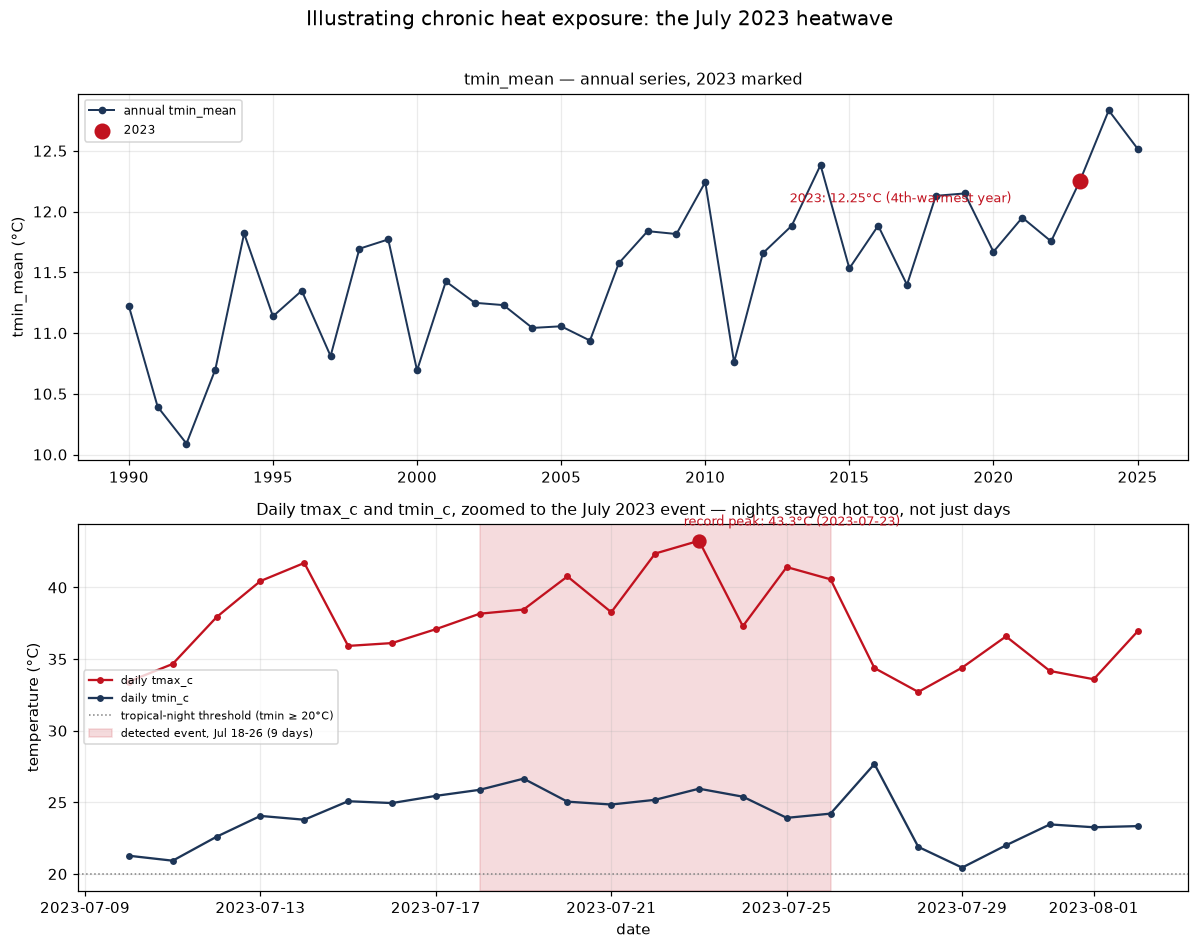

During the 9-day event: tmax ranged 37.3-43.3°C, tmin ranged 23.9-26.7°C (never dropped below the 20°C tropical-night threshold on any of the 9 nights).


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))

# --- Top: annual tmin_mean, 1990-2025, 2023 marked ---
ax = axes[0]
y = indicators["tmin_mean"]
ax.plot(y.index, y.values, "o-", color="#1d3557", lw=1.3, ms=4, label="annual tmin_mean")
ax.scatter([2023], [y.loc[2023]], color="#c1121f", s=90, zorder=6, label="2023")
ax.annotate(f"2023: {y.loc[2023]:.2f}°C (4th-warmest year)", (2023, y.loc[2023]),
            textcoords="offset points", xytext=(-190, -14), fontsize=8.5, color="#c1121f")
ax.set_title("tmin_mean — annual series, 2023 marked", fontsize=10.5)
ax.set_ylabel("tmin_mean (°C)")
ax.legend(fontsize=8, loc="upper left")

# --- Bottom: daily tmax_c and tmin_c, zoomed to the July 2023 event ---
ax = axes[1]
window = daily[(daily["valid_time"] >= "2023-07-10") & (daily["valid_time"] <= "2023-08-02")]
ax.plot(window["valid_time"], window["tmax_c"], "-o", color="#c1121f", lw=1.5, ms=3.5, label="daily tmax_c")
ax.plot(window["valid_time"], window["tmin_c"], "-o", color="#1d3557", lw=1.5, ms=3.5, label="daily tmin_c")
ax.axhline(20, color="gray", linestyle=":", lw=1, label="tropical-night threshold (tmin ≥ 20°C)")

ax.axvspan(pd.Timestamp("2023-07-18"), pd.Timestamp("2023-07-26"), color="#c1121f", alpha=0.15,
           label="detected event, Jul 18-26 (9 days)")

peak_row = window.loc[window["tmax_c"].idxmax()]
ax.scatter([peak_row["valid_time"]], [peak_row["tmax_c"]], color="#c1121f", s=70, zorder=6)
ax.annotate(f"record peak: {peak_row['tmax_c']:.1f}°C ({peak_row['valid_time'].date()})",
            (peak_row["valid_time"], peak_row["tmax_c"]),
            textcoords="offset points", xytext=(-10, 10), fontsize=8.5, color="#c1121f")

ax.set_title("Daily tmax_c and tmin_c, zoomed to the July 2023 event — nights stayed hot too, "
             "not just days", fontsize=10.5)
ax.set_ylabel("temperature (°C)")
ax.set_xlabel("date")
ax.legend(fontsize=7.5, loc="center left")

fig.suptitle("Illustrating chronic heat exposure: the July 2023 heatwave", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

event = daily[(daily["valid_time"] >= "2023-07-18") & (daily["valid_time"] <= "2023-07-26")]
print(f"During the 9-day event: tmax ranged {event['tmax_c'].min():.1f}-{event['tmax_c'].max():.1f}°C, "
      f"tmin ranged {event['tmin_c'].min():.1f}-{event['tmin_c'].max():.1f}°C (never dropped below the "
      f"20°C tropical-night threshold on any of the 9 nights).")

## 14. Testing `min_spi3` through the same CV rigor as the headline three

`min_spi3` was excluded from sections 6-8 by design (section 4 found it flat-to-improving and
uncorrelated with the flood side), so its baseline everywhere downstream (`larissa_cmip6_projection_eda.ipynb`
Section 16, `Results_Summary.ipynb`) has been a plain, unvalidated full-history OLS fit shown next to
`naive_full_mean` for comparison, not a CV-validated recommendation. Given the projection-vs-history
drought reversal found in `Calculating_SPI_for_Larissa_Projection.ipynb` is being presented as a real
finding, it's worth closing that gap: does anything actually beat naive for `min_spi3`, using the
identical single-split and walk-forward-CV methodology sections 6-7 used for the other three
indicators? Reuses `fit_and_evaluate`/`fit_and_evaluate_at`/`OLS_WINDOWS`/`SPLIT_POINTS` exactly as
already defined above -- nothing redefined.


In [16]:
min_spi3_hist = pd.read_csv(f"{OUT}/larissa_volatility_annual.csv", index_col=0)["min_spi3"]
min_spi3_hist.index.name = "year"

r_single = fit_and_evaluate(min_spi3_hist)
print(f"Single-split (train {int(r_single['yrs_train'].min())}-{int(r_single['yrs_train'].max())}, "
      f"test {int(r_single['yrs_test'].min())}-{int(r_single['yrs_test'].max())}):")
print(pd.Series(r_single["mae"]).sort_values().round(4).to_string())
print(f"Best model: {r_single['best_model']}  (beats naive: {r_single['beats_naive']})")


Single-split (train 1990-2017, test 2018-2025):
ols_last_10yr       0.4153
ols_last_20yr       0.4219
ols_full_history    0.4524
naive_full_mean     0.5626
ols_last_15yr       0.6730
Best model: ols_last_10yr  (beats naive: True)


In [17]:
cv_rows = []
for label, start_year in SPLIT_POINTS:
    r = fit_and_evaluate_at(min_spi3_hist, start_year)
    if r is None:
        continue
    row = {"test_window": label, "best_model": r["best_model"]}
    row.update({f"mae_{k}": v for k, v in r["mae"].items()})
    cv_rows.append(row)

cv_table_spi3 = pd.DataFrame(cv_rows).set_index("test_window")
display(cv_table_spi3.round(4))

avg_mae_spi3 = (cv_table_spi3[[c for c in cv_table_spi3.columns if c.startswith("mae_")]]
                .mean().rename(lambda s: s.replace("mae_", "")))
print("\nAverage MAE across all 3 splits, ranked:")
print(avg_mae_spi3.sort_values().round(4).to_string())

naive_avg = avg_mae_spi3["naive_full_mean"]
best_name = avg_mae_spi3.idxmin()
best_avg = avg_mae_spi3.min()
consistent = cv_table_spi3["best_model"].nunique() == 1
print(f"\nwinner per split: {cv_table_spi3['best_model'].to_dict()}")
print(f"consistent across all 3 splits: {consistent}")
print(f"CV-average winner: {best_name}  (naive={naive_avg:.4f}, best={best_avg:.4f}, "
      f"improvement={100*(naive_avg-best_avg)/naive_avg:+.1f}%)")


,best_model,mae_naive_full_mean,mae_ols_full_history,mae_ols_last_20yr,mae_ols_last_15yr,mae_ols_last_10yr
test_window,,,,,,
2011-2018,ols_last_20yr,0.4014,0.4431,0.3890,0.3945,0.4024
2014-2021,ols_full_history,0.4126,0.3237,0.5210,0.4585,0.8858
2018-2025,ols_last_10yr,0.5626,0.4524,0.4219,0.6730,0.4153



Average MAE across all 3 splits, ranked:
ols_full_history    0.4064
ols_last_20yr       0.4440
naive_full_mean     0.4589
ols_last_15yr       0.5087
ols_last_10yr       0.5678

winner per split: {'2011-2018': 'ols_last_20yr', '2014-2021': 'ols_full_history', '2018-2025': 'ols_last_10yr'}
consistent across all 3 splits: False
CV-average winner: ols_full_history  (naive=0.4589, best=0.4064, improvement=+11.4%)


### 14.1 Finding: `min_spi3` does have a validated baseline after all -- `ols_full_history`

**This is not the result expected going in.** Section 4's original exclusion reasoning ("flat-to-
improving, uncorrelated with the flood side") was about `min_spi3`'s relationship to the *other*
indicators, not about whether a year-trend model can beat naive for `min_spi3` on its own -- and on
that specific question, the answer turns out to be yes, reasonably robustly:

- **Single-split** (train 1990-2017, test 2018-2025): `ols_last_10yr` wins clearly (MAE 0.415 vs.
  naive's 0.563, a 26% improvement).
- **Walk-forward CV** (3 splits): `ols_full_history` has the lowest average MAE (0.406 vs. naive's
  0.459, an **11.4% improvement**) -- both views agree a regression beats naive, they just disagree on
  which window, the same "real improvement, unstable window" pattern seen for `tmin_mean` and
  `precip_scaled` in sections 6-7.
- **Not perfectly consistent**: the per-split winner changes each time (`ols_last_20yr` /
  `ols_full_history` / `ols_last_10yr`) -- weaker than `tmin_mean`'s result (where multiple windows
  beat naive at *every* individual split), but clearly stronger than `days_fwi_gt30`'s equivalent
  check for Seville (1.8% edge, barely above noise) or Seville's own `min_spi3` (0.5% edge, doesn't
  even hold at every split).

**Practical consequence**: the `ols_full_history` baseline already being shown for `min_spi3` in
`larissa_cmip6_projection_eda.ipynb` Section 16 and `Results_Summary.ipynb` -- previously labeled "not
CV-validated, shown for comparison only" -- turns out to be exactly the CV-average winner. No plot
needs to change; the *caveat* attached to it does. This also means the drought-reversal finding
(historical `min_spi3` trend positive/improving vs. the projection's trend reversing to negative) now
rests on a validated baseline model, not an arbitrary unvalidated one -- a real increase in how much
that finding can be trusted.


## Next steps

- ~~Run the SSP5-8.5 projection comparison per section 10 above~~ -- done, see section 10's updated
  discussion and `larissa_cmip6_projection_eda.ipynb` Section 16/19 for the full comparison plots and
  synthesis. The result is more interesting than "confirmed" or "not confirmed": `tmin_mean` confirms
  cleanly, `precip_scaled`/`max_week_precip_mm` reverse direction entirely.
- **New follow-up, raised by section 10's finding**: the precipitation-side reversal (all three
  precipitation-derived indicators diverging from a statistically significant historical trend) is
  exactly the kind of single-model result that most needs a second model or scenario to check before
  it changes how Larissa's flood risk gets presented. The bias-corrected source data already extends
  to 2061 (`data/larissa_cmip6_ssp585_2026_2061_biascorrected.csv`) if a longer window is wanted as a
  first check, though a genuinely independent check would need a second CMIP6 model, not just a
  longer run of the same one.
- If a genuine multivariate model is built on top of these three, note that `max_week_precip_mm` is
  not independently significant on its own (OLS p=0.0546) and its best model depends on
  `precip_scaled` rather than time alone -- any composite claim built from these three should treat
  `precip_scaled` and `max_week_precip_mm` as one coupled axis, not two independent contributors,
  consistent with the section 4 correlation-structure finding.
- Compare directly against `Climate_Indicators_Modeling.ipynb` (Seville): both notebooks now share
  an identical pipeline and evaluation framework, so the two cities' indicator sets can be
  contrasted directly -- Seville's mediated three-way pathway (heat -> drought -> fire duration) vs.
  Larissa's two-axis structure (chronic uniform heat, independent of a precipitation-intensity axis
  that is itself internally coupled) -- and, now that both have projection results, whether the
  projection confirms or reverses each city's historical story is itself a third point of contrast:
  Seville's projection direction stays broadly consistent with its history; Larissa's does not, on
  the precipitation side.
